### **Import Libraries**


In [1]:
from keras.models import load_model
import os
import cv2
import matplotlib.pyplot as plt
import sys

sys.path.insert(
    0,
    "D:\Automatic Blur Severity Classification and Image Restoration Using CNNs and U-Net\CODE\library",
)
from utils import psnr, ssim, save_image
from keras.utils import load_img
import numpy as np
import pandas as pd

### **Load Model**

In [2]:
parent_dir = r"D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI"

### **Classification Model**

In [5]:
classification_model = load_model(os.path.join(parent_dir,os.path.join(parent_dir,"integrated_system\Classification Models\Blur Severity Classification Model\severity_gaussian_model.h5")))

### **Deblurring Model**

In [6]:
def load_custom_metric_model(model_path, custom_metrics):
    return load_model(model_path, custom_objects=custom_metrics)


# Define model paths
model_paths = [
    "gaussian_blur_very_low.h5",
    "gaussian_blur_low.h5",
    "gaussian_blur_medium.h5",
    "gaussian_blur_high.h5",
    "gaussian_blur_very_high.h5",
]

# Custom metrics dictionary
custom_metrics = {"ssim": ssim, "psnr": psnr}

# Load models
models = []
for model_path in model_paths:
    full_model_path = os.path.join(
        parent_dir,
        "facial_image_deblurring",
        "experiments",
        "gaussian_blur_experiments",
        "models",
        model_path,
    )
    model = load_custom_metric_model(full_model_path, custom_metrics)
    models.append(model)

# Assign models to respective variables
very_low_model, low_model, medium_model, high_model, very_high_model = models

In [7]:
combined_deblur_model = load_model(
    os.path.join(
        parent_dir,
        r"facial_image_deblurring\experiments\gaussian_blur_combined_experiments\models\gaussian_blur_combined_combined.h5",
    ),
    custom_objects=custom_metrics,
)

OSError: No file or directory found at D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\facial_image_deblurring\experiments\gaussian_blur_combined_experiments\models\gaussian_blur_combined_combined.h5

In [8]:
# Example usage:
deblur_models = {
    "very_low": very_low_model,
    "low": low_model,
    "medium": medium_model,
    "high": high_model,
    "very_high": very_high_model,
}

In [9]:
class_labels = ["high", "low", "medium", "very_high", "very_low"]

In [10]:
def predict_and_deblur(
    blurry_image_path, real_image_path, classification_model, deblur_models, class_labels
):
    # Load and preprocess the image
    blurry_img = cv2.imread(blurry_image_path)
    blurry_img = cv2.cvtColor(blurry_img, cv2.COLOR_BGR2RGB)
    blurry_img = blurry_img.astype("float32") / 255.0
    blurry_img_expanded = np.expand_dims(blurry_img, axis=0)

    real_img = cv2.imread(real_image_path)
    real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)
    real_img = real_img.astype("float32") / 255.0
    real_img_expanded = np.expand_dims(real_img, axis=0)

    # Predict the blur level
    predicted_level_probs = classification_model.predict(blurry_img_expanded)[0]
    predicted_level_idx = np.argmax(predicted_level_probs)
    predicted_level = class_labels[predicted_level_idx]
    accuracy_percentage = predicted_level_probs[predicted_level_idx] * 100

    print("Blur level:", predicted_level)
    print("Classification Accuracy:", accuracy_percentage, "%")

    # Deblur the image
    deblurring_model = deblur_models[predicted_level]
    deblurring_image = deblurring_model.predict(blurry_img_expanded)[0]

    # Calculate SSIM and PSNR
    ssim_value_before = ssim(real_img, blurry_img)
    ssim_value_after = ssim(real_img, deblurring_image)
    print("SSIM Score Before:", ssim_value_before)
    print("SSIM Score After:", ssim_value_after)

    psnr_value_before = psnr(real_img, blurry_img)
    psnr_value_after = psnr(real_img, deblurring_image)
    print("PSNR Score Before:", psnr_value_before)
    print("PSNR Score After:", psnr_value_after)

    # Plot the images with the predicted class and accuracy
    plt.figure(figsize=(6, 3))

    # Blurry image with predicted class
    plt.subplot(1, 3, 1)
    plt.imshow(blurry_img)
    plt.title(f"Blurry Image")
    plt.axis('off')

    # Deblurred image
    plt.subplot(1, 3, 2)
    plt.imshow(deblurring_image)
    plt.title("Deblurred Image")
    plt.axis('off')

    # Real image
    plt.subplot(1, 3, 3)
    plt.imshow(real_img)
    plt.title("Real Image")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return predicted_level, accuracy_percentage, real_img, deblurring_image

In [11]:
blur_level="very_high"

In [14]:
blurry_image_path = r"D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\dataset\For Deblurring\blur_severity_level\gaussian_blur\test\X\very_high\blurry_image_1.png"
original_image_path = r"D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\dataset\For Deblurring\blur_severity_level\gaussian_blur\test\Y\very_high\blurry_image_1.png"

1/1 [==============================] - 9s 9s/step
Blur level: very_high
Classification Accuracy: 99.99090433120728 %
1/1 [==============================] - 2s 2s/step
SSIM Score Before: tf.Tensor(0.5560053, shape=(), dtype=float32)
SSIM Score After: tf.Tensor(0.8094933, shape=(), dtype=float32)
PSNR Score Before: tf.Tensor(19.807503, shape=(), dtype=float32)
PSNR Score After: tf.Tensor(26.410828, shape=(), dtype=float32)


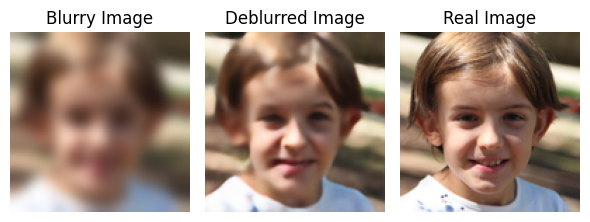

In [15]:
predicted_class, accuracy_percentage, real_image, deblurred_image = predict_and_deblur(
    blurry_image_path,
    original_image_path,
    classification_model,
    deblur_models,
    class_labels,
)

In [16]:
def predict_and_deblur_combined_model(blurry_image_path, real_image_path, deblur_model):

    # Load and preprocess the image

    blurry_img = cv2.imread(blurry_image_path)
    blurry_img = cv2.cvtColor(blurry_img, cv2.COLOR_BGR2RGB)
    blurry_img = blurry_img.astype("float32") / 255.0
    blurry_img = np.expand_dims(blurry_img, axis=0)

    real_img = cv2.imread(real_image_path)
    real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)
    real_img = real_img.astype("float32") / 255.0
    real_img = np.expand_dims(real_img, axis=0)

    deblurring_image = deblur_model.predict(blurry_img)[0]
    ssim_value_before = ssim(real_img, blurry_img)
    ssim_value_after = ssim(real_img, deblurring_image)
    print("ssim Score Before: ", ssim_value_before)
    print("ssim Score After: ", ssim_value_after)
    psnr_value_before = psnr(real_img, blurry_img)
    psnr_value_after = psnr(real_img, deblurring_image)
    print("psnr Score Before: ", psnr_value_before)
    print("psnr Score After: ", psnr_value_after)
    return deblurring_image

In [17]:
deblurred_image_combined = predict_and_deblur_combined_model(
    blurry_image_path, original_image_path, combined_deblur_model
)

NameError: name 'combined_deblur_model' is not defined

In [ ]:
test_parent_save_path=fr"D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\integrated_system\test\{blur_level}"
os.makedirs(test_parent_save_path, exist_ok=True)

In [ ]:
# Visualize the result
plt.figure(figsize=(3, 3))

# Display the predicted class text

# Display the blurry image
plt.title(
    f"Predicted Class: {predicted_class}\nAccuracy: {accuracy_percentage:.3f}%",
    fontsize=14,
)
plt.imshow(load_img(blurry_image_path))
plt.axis("off")

# Save the plot with adjusted layout to avoid cropping the title
save_path = os.path.join(test_parent_save_path, "predicted_class.png")
plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1)

plt.tight_layout()
plt.show()

In [ ]:
save_image(deblurred_image, os.path.join(test_parent_save_path, "deblurred_img.png"))

In [ ]:
save_image(real_image, os.path.join(test_parent_save_path, "real_img.png"))